In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Set up professional plot display
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

# Ensure reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load isolated Train and Test datasets directly
print("🎯 Loading Train and Test datasets...")
train_df_raw = pd.read_csv('../features/train_ml_features.csv')
test_df_raw = pd.read_csv('../features/test_ml_features.csv')

# Convert to Datetime
train_df_raw['order_date'] = pd.to_datetime(train_df_raw['order_date'])
test_df_raw['order_date'] = pd.to_datetime(test_df_raw['order_date'])

# Temporarily concatenate to calculate continuous lag features for LSTM 
# without missing the first 7 days of the Test set
df_combined = pd.concat([train_df_raw, test_df_raw]).sort_values(['stock_code', 'order_date']).reset_index(drop=True)

# Establish a 7-day sliding window for time-series features
for i in range(1, 8):
    df_combined[f'lstm_lag_{i}'] = df_combined.groupby('stock_code')['daily_quantity'].shift(i)

# Drop NaN values generated in the earliest days of the Train set
df_combined = df_combined.dropna().reset_index(drop=True)


🎯 Loading Train and Test datasets...


In [2]:
#==========================================================================
# STRICT CHRONOLOGICAL SPLITTING (PREVENT DATA LEAKAGE & FIX SORTING)
# =========================================================================
# 1. Isolate Test Set: All data from Nov 1, 2010 onwards
test_mask = df_combined['order_date'] >= '2010-11-01'
test_df = df_combined[test_mask].sort_values(['stock_code', 'order_date']).reset_index(drop=True)

# 2. Isolate Train & Val Sets: All data up to Oct 31, 2010
full_train_df = df_combined[~test_mask].copy()

# BUG FIX: Sort purely by 'order_date' before performing the 80/20 split.
# This ensures the Validation set always contains the most recent temporal data for ALL items.
full_train_df = full_train_df.sort_values('order_date').reset_index(drop=True)

# Slice the oldest 80% of data for Training, and the newest 20% for Validation (Early Stopping)
split_idx = int(len(full_train_df) * 0.8)
train_df = full_train_df.iloc[:split_idx]
val_df = full_train_df.iloc[split_idx:]

# MANDATORY RE-SORT: Sort back by 'stock_code' -> 'order_date'.
# Models (especially LSTM) must read the continuous chronological sequence of each individual product.
train_df = train_df.sort_values(['stock_code', 'order_date']).reset_index(drop=True)
val_df = val_df.sort_values(['stock_code', 'order_date']).reset_index(drop=True)

print(f"📊 Time-Series Decomposition Results (Strict Chronological Split):")
print(f"   -> Training Set:   {train_df.shape[0]:,} samples ({train_df['order_date'].min().strftime('%Y-%m-%d')} to {train_df['order_date'].max().strftime('%Y-%m-%d')})")
print(f"   -> Validation Set: {val_df.shape[0]:,} samples ({val_df['order_date'].min().strftime('%Y-%m-%d')} to {val_df['order_date'].max().strftime('%Y-%m-%d')})")
print(f"   -> Testing Set:    {test_df.shape[0]:,} samples ({test_df['order_date'].min().strftime('%Y-%m-%d')} to {test_df['order_date'].max().strftime('%Y-%m-%d')})")
final_predictions = {}

# Define columns to be excluded from direct training
ignored_cols = ['stock_code', 'order_date', 'daily_quantity']
lstm_lag_cols = [f'lstm_lag_{i}' for i in range(1, 8)]

# 1. Feature configuration for Tree-based models (Keep categorical variables in numerical format)
tree_features = [col for col in train_df.columns if col not in ignored_cols and col not in lstm_lag_cols]
X_train_tree = train_df[tree_features]
X_val_tree = val_df[tree_features]
X_test_tree = test_df[tree_features]

y_train = train_df['daily_quantity']
y_val = val_df['daily_quantity']
y_test = test_df['daily_quantity']

# Revert the target variable y_test to its original scale for metric calculation
y_test_original = np.expm1(y_test).values

# 2. Feature configuration for Linear models (Apply One-Hot Encoding on the combined dataset)
# Transformation must occur on the full set to ensure consistent column dimensions, then split using the Mask
df_encoded = pd.get_dummies(df_combined, columns=['month', 'day_of_week'], drop_first=True, dtype=int)
linear_features = [col for col in df_encoded.columns if col not in ignored_cols and col not in lstm_lag_cols]

test_mask_encoded = df_encoded['order_date'] >= '2010-11-01'
X_test_linear = df_encoded[test_mask_encoded].sort_values(['stock_code', 'order_date']).reset_index(drop=True)[linear_features]

full_train_encoded = df_encoded[~test_mask_encoded].sort_values(['stock_code', 'order_date']).reset_index(drop=True)
X_train_linear = full_train_encoded.iloc[:split_idx][linear_features]
X_val_linear = full_train_encoded.iloc[split_idx:][linear_features]

# 3. Initialize the traditional Machine Learning models dictionary
ml_models = {
    'Multiple Linear': (LinearRegression(), X_train_linear, X_test_linear),
    'Ridge Regression': (Ridge(alpha=1.0), X_train_linear, X_test_linear),
    'Random Forest': (RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1), X_train_tree, X_test_tree),
    'LightGBM': (lgb.LGBMRegressor(n_estimators=150, learning_rate=0.06, random_state=42, verbose=-1, n_jobs=-1), X_train_tree, X_test_tree),
    'XGBoost': (xgb.XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.06, random_state=42, n_jobs=-1), X_train_tree, X_test_tree)
}

print("\n[Training Traditional Machine Learning Models]")
for name, (model, X_tr, X_te) in ml_models.items():
    print(f"   -> Training model: {name}...")
    model.fit(X_tr, y_train)
    pred_log = model.predict(X_te)
    
    # Revert from Log scale to actual product quantity and set the lower bound to 0
    final_predictions[name] = np.clip(np.expm1(pred_log), 0, None)

print("✅ Successfully stored forecast results for the 5 traditional models.")
print("\n[Training Deep Sequential LSTM Network]")

# 1. Extract 7-day continuous time-series (Sorted chronologically from oldest to newest)
lstm_features = [f'lstm_lag_{i}' for i in [7, 6, 5, 4, 3, 2, 1]]

# 2. Synchronized Data Scaling for X and Y (Fit parameters ONLY on the Training set)
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(train_df[lstm_features])
X_val_scaled = scaler_X.transform(val_df[lstm_features])
X_test_scaled = scaler_X.transform(test_df[lstm_features])

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(np.array(y_train).reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(np.array(y_val).reshape(-1, 1)).flatten()

# 3. Transform matrix into 3D input structure for sequential networks: [Samples, Timesteps=7, Features=1]
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 7, 1))
X_val_lstm = X_val_scaled.reshape((X_val_scaled.shape[0], 7, 1))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 7, 1))

# 4. Build the LSTM network architecture for time-series learning
lstm_model = Sequential([
    LSTM(32, activation='tanh', input_shape=(7, 1), return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

# 5. Configure advanced Early Stopping to prevent overfitting due to SKU noise variance
early_stop = EarlyStopping(monitor='val_loss', patience=10, min_delta=1e-4, restore_best_weights=True)

print("   -> Executing weight optimization epochs (Max 50 Epochs)...")
lstm_model.fit(
    X_train_lstm, y_train_scaled, 
    epochs=50, 
    batch_size=64, # Common choice based on empirical system performance
    validation_data=(X_val_lstm, y_val_scaled), 
    callbacks=[early_stop], 
    verbose=1
)

# 6. Forecast and execute inverse scaling protocol (Inverse Scaling and Expm1)
lstm_pred_scaled = lstm_model.predict(X_test_lstm).flatten()
lstm_pred_log = scaler_y.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()
final_predictions['LSTM'] = np.clip(np.expm1(lstm_pred_log), 0, None)

# 7. Initialize Naive Baseline from raw lag_1 value (Ensure unit is restored to original scale)
# Since lag_1 is in log scale, apply expm1 to revert it to the original scale for fair comparison
final_predictions['Naive Baseline'] = np.clip(np.expm1(X_test_tree['lag_1'].values), 0, None)

📊 Time-Series Decomposition Results (Strict Chronological Split):
   -> Training Set:   152,220 samples (2009-12-16 to 2010-09-15)
   -> Validation Set: 38,056 samples (2010-09-15 to 2010-10-31)
   -> Testing Set:    36,818 samples (2010-11-01 to 2010-12-09)

[Training Traditional Machine Learning Models]
   -> Training model: Multiple Linear...
   -> Training model: Ridge Regression...
   -> Training model: Random Forest...
   -> Training model: LightGBM...
   -> Training model: XGBoost...
✅ Successfully stored forecast results for the 5 traditional models.

[Training Deep Sequential LSTM Network]
   -> Executing weight optimization epochs (Max 50 Epochs)...
Epoch 1/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0124 - val_loss: 0.0125
Epoch 2/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0123 - val_loss: 0.0125
Epoch 3/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0123 - val_loss: 0.0125
Epoch 4/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0123


📊 OVERALL PERFORMANCE EVALUATION ON ORIGINAL PRODUCT SCALE:
---------------------------------------------------------------------------------------------------------
Algorithm / Model    | RMSE       | MAE        | R² Score   | Correlation  | MAPE (%)
---------------------------------------------------------------------------------------------------------
Multiple Linear      | 66.76      | 17.97      | -0.0401    | 0.2214       | 191.05%
Ridge Regression     | 66.76      | 17.97      | -0.0401    | 0.2215       | 191.05%
Random Forest        | 58.70      | 14.35      | 0.1959     | 0.4720       | 148.34%
LightGBM             | 59.35      | 14.41      | 0.1781     | 0.4734       | 127.53%
XGBoost              | 58.18      | 13.95      | 0.2102     | 0.4896       | 160.65%
LSTM                 | 63.56      | 15.29      | 0.0573     | 0.3915       | 137.78%
Naive Baseline       | 80.82      | 20.65      | -0.5240    | 0.2004       | 205.90%
----------------------------------------------

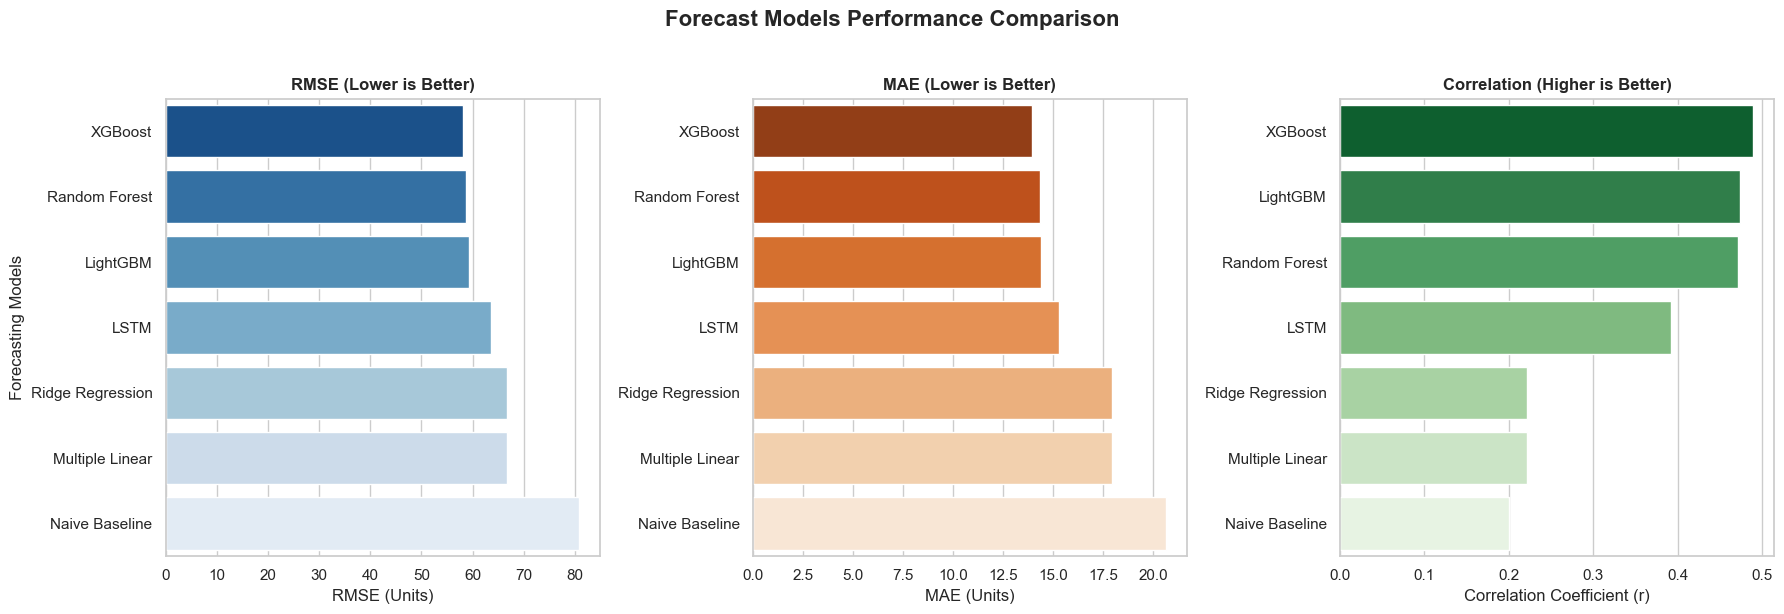

✅ Saved metrics comparison chart to: ../src/outputs/images/4_1_model_evaluation_metrics.png

🎉 DATA FILE SUCCESSFULLY EXPORTED TO: '../features/stage_4_input_predictions.csv'


In [3]:
# ------------------------------------------------------------------
# COMPREHENSIVE EVALUATION AND STATISTICAL REPORT (7 MODELS)
# ------------------------------------------------------------------
import os

def safe_mape(y_true, y_pred):
    mask = y_true > 0
    if np.sum(mask) == 0: return 0.0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def safe_correlation(y_true, y_pred):
    if np.std(y_pred) == 0 or np.std(y_true) == 0:
        return 0.0
    return np.corrcoef(y_true, y_pred)[0, 1]

# 1. Collect all metrics into a Pandas DataFrame
metrics_list = []
for name, pred in final_predictions.items():
    rmse = np.sqrt(mean_squared_error(y_test_original, pred))
    mae = mean_absolute_error(y_test_original, pred)
    r2 = r2_score(y_test_original, pred)
    corr = safe_correlation(y_test_original, pred)
    mape = safe_mape(y_test_original, pred)
    
    metrics_list.append({
        'Model': name, 
        'RMSE': rmse, 
        'MAE': mae, 
        'R2 Score': r2, 
        'Correlation': corr, 
        'MAPE (%)': mape
    })

df_metrics = pd.DataFrame(metrics_list)

# 2. Print the Statistical Table
print("\n📊 OVERALL PERFORMANCE EVALUATION ON ORIGINAL PRODUCT SCALE:")
print("-" * 105)
print(f"{'Algorithm / Model':<20} | {'RMSE':<10} | {'MAE':<10} | {'R² Score':<10} | {'Correlation':<12} | {'MAPE (%)'}")
print("-" * 105)
for _, row in df_metrics.iterrows():
    print(f"{row['Model']:<20} | {row['RMSE']:<10.2f} | {row['MAE']:<10.2f} | {row['R2 Score']:<10.4f} | {row['Correlation']:<12.4f} | {row['MAPE (%)']:.2f}%")
print("-" * 105)

# 3. Plot the Performance Metrics Comparison Chart
print("\n[Generating Metrics Comparison Chart...]")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot RMSE (Lower is better)
sns.barplot(x='RMSE', y='Model', data=df_metrics.sort_values('RMSE'), ax=axes[0], palette='Blues_r')
axes[0].set_title('RMSE (Lower is Better)', fontweight='bold')
axes[0].set_xlabel('RMSE (Units)')
axes[0].set_ylabel('Forecasting Models')

# Plot MAE (Lower is better)
sns.barplot(x='MAE', y='Model', data=df_metrics.sort_values('MAE'), ax=axes[1], palette='Oranges_r')
axes[1].set_title('MAE (Lower is Better)', fontweight='bold')
axes[1].set_xlabel('MAE (Units)')
axes[1].set_ylabel('')

# Plot Correlation (Higher is better)
sns.barplot(x='Correlation', y='Model', data=df_metrics.sort_values('Correlation', ascending=False), ax=axes[2], palette='Greens_r')
axes[2].set_title('Correlation (Higher is Better)', fontweight='bold')
axes[2].set_xlabel('Correlation Coefficient (r)')
axes[2].set_ylabel('')

# Layout adjustments
plt.suptitle('Forecast Models Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the chart to the images folder
os.makedirs('../src/outputs/images/', exist_ok=True)
metrics_chart_path = '../src/outputs/images/4_1_model_evaluation_metrics.png'
plt.savefig(metrics_chart_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"✅ Saved metrics comparison chart to: {metrics_chart_path}")

# ------------------------------------------------------------------
# SYNCHRONIZED OUTPUT EXPORT FOR STAGE 4
# ------------------------------------------------------------------
df_stage_4 = test_df[['stock_code', 'order_date']].copy()
df_stage_4['actual_quantity'] = np.round(y_test_original).astype(int)

for name, pred in final_predictions.items():
    col_name = f"pred_{name.lower().replace(' ', '_')}"
    df_stage_4[col_name] = np.clip(np.round(pred, 2), 0, None)  # Clip lower bounds to 0

# Set direct output path for Stage 4 (Ensure directory exists prior to execution)
output_path = '../features/stage_4_input_predictions.csv'
df_stage_4.to_csv(output_path, index=False)

print(f"\n🎉 DATA FILE SUCCESSFULLY EXPORTED TO: '{output_path}'")

In [5]:
# ==================================================================
# 4. PLOT ACTUAL VS FORECAST FOR TOP SKU (CASE STUDY)
# ==================================================================
import plotly.graph_objects as go
import os

print("\n[Generating Actual vs Forecast Line Chart for Top SKU...]")

# Identify the Top SKU (Best-selling item based on actual data)
top_sku = df_stage_4['stock_code'].value_counts().index[0]
df_filtered = df_stage_4[df_stage_4['stock_code'] == top_sku].sort_values(by='order_date')

fig_line = go.Figure()

# Plot the Actual demand line - Green, solid, thick
fig_line.add_trace(go.Scatter(
    x=df_filtered['order_date'], 
    y=df_filtered['actual_quantity'], 
    name='Actual Demand', 
    line=dict(color='#2ca02c', width=3),
))

# Get the list of prediction columns
pred_cols = [col for col in df_filtered.columns if str(col).startswith('pred_')]
colors = ['#1f77b4', '#ff7f0e', '#9467bd', '#8c564b', '#e377c2', '#17becf', '#7f7f7f']

# Plot prediction lines (Highlight XGBoost instead of Ridge)
for i, col_name in enumerate(pred_cols):
    model_name = col_name.replace('pred_', '').replace('_', ' ').title()
    
    # Highlight XGBoost (The New Champion)
    if "xgboost" in col_name.lower():
        # XGBoost gets the prominent red dotted line
        line_style = dict(color='red', width=3, dash='dot')
        trace_name = f"⭐ {model_name} (Champion)"
    else:
        # Ridge and all others get standard thin dashed lines
        line_style = dict(color=colors[i % len(colors)], width=1, dash='dash')
        trace_name = model_name

    fig_line.add_trace(go.Scatter(
        x=df_filtered['order_date'], 
        y=df_filtered[col_name], 
        name=trace_name, 
        line=line_style
    ))

# Customize layout for academic paper presentation
fig_line.update_layout(
    title=f"Demand Forecasting Trends for Top SKU: {top_sku} (XGBoost vs Others)",
    xaxis_title="Time (Order Date)",
    yaxis_title="Quantity Sold",
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.2,
        xanchor="center",
        x=0.5
    ),
    template="plotly_white",
)

# Save the image file
os.makedirs('../src/outputs/images/', exist_ok=True)
png_path = '../src/outputs/images/4_1b_forecast_vs_actual_top_sku.png'
try:
    fig_line.write_image(png_path, scale=2)
    print(f"✅ Saved Line Chart to: {png_path}")
except Exception as exc:
    print(f"⚠️ Could not save PNG automatically (Missing Kaleido package): {exc}")

# Display the chart
fig_line.show()
print("✅ BENCHMARKING PROCESS FULLY COMPLETED!")


[Generating Actual vs Forecast Line Chart for Top SKU...]
✅ Saved Line Chart to: ../src/outputs/images/4_1b_forecast_vs_actual_top_sku.png


✅ BENCHMARKING PROCESS FULLY COMPLETED!
